# 02b — Backbone y Clasificacion v2

**Diferencias respecto al notebook 02 original**

- Usa `nih_clean.csv` en lugar de `master.csv` + `Data_Entry_2017.csv`. El CSV fue
  preprocesado por el equipo: contiene solo vistas PA, sin duplicados, sin valores
  nulos, con columnas patient_id y patient_age ya integradas.
- Entrena con todas las imagenes anomalas disponibles en train (~19,405) mas igual
  numero de normales — casi el doble que el modelo original (20,000).
- Soporta entrenamiento en dos dias: la Fase 1 y la Fase 2 se pueden ejecutar en
  sesiones de Colab distintas gracias a la deteccion automatica de checkpoints.
- Incluye calculo de matriz de confusion, sensibilidad y especificidad.
- Todos los archivos generados tienen sufijo _v2 para no sobreescribir el modelo original.

**Archivos que produce este notebook**
- `Vena/checkpoints/mejor_modelo_clasificacion_v2.h5` — modelo completo, el mejor segun val_loss
- `Vena/checkpoints/backbone_densenet121_v2.h5` — backbone para reutilizar en NB03 y NB04
- `Vena/checkpoints/curvas_entrenamiento_clasificacion_v2.png` — curvas de loss y AUC
- `Vena/checkpoints/matriz_confusion_clasificacion_v2.png` — matriz de confusion en test

**Prerequisito**
- `nih_clean.csv` subido a `Vena/Notebooks/Datasets/`
- `nih_resized_224.zip` y `chest_xray.zip` en `Vena/Notebooks/Datasets/`

---

**Instrucciones para entrenamiento en dos dias**

Dia 1 — Fase 1:
1. Seleccionar GPU en Entorno de ejecucion
2. Ejecutar celdas 1 a 12 en orden
3. Esperar a que termine la Fase 1 (~1.7 horas)
4. Verificar que el checkpoint se guardo en Drive y cerrar Colab

Dia 2 — Fase 2:
1. Seleccionar GPU en Entorno de ejecucion
2. Ejecutar celdas 1 a 10 (preparacion de datos y generadores)
3. Ejecutar celda 11 (deteccion de checkpoint — cargara el modelo del Dia 1)
4. Saltar la celda 12 (Fase 1) — ya esta hecha
5. Ejecutar celda 13 (Fase 2) y las siguientes

## Celda 1 — Verificacion de GPU

Lo primero que se hace en cada sesion es confirmar que Colab asigno una GPU.
Si esta celda muestra 'No se encontro GPU', detener aqui y cambiar el tipo de
entorno de ejecucion antes de continuar. Entrenar en CPU es entre 10 y 50 veces
mas lento y la sesion de Colab se agotara antes de terminar un solo epoch.

In [1]:
import tensorflow as tf

gpus_disponibles = tf.config.list_physical_devices('GPU')

if gpus_disponibles:
    print(f"GPU encontrada: {gpus_disponibles[0].name}")
    print("El entrenamiento usara aceleracion por GPU.")
else:
    print("No se encontro GPU.")
    print("Ir a: Entorno de ejecucion > Cambiar tipo de entorno > GPU")
    print("Detener la ejecucion hasta resolver esto.")

GPU encontrada: /physical_device:GPU:0
El entrenamiento usara aceleracion por GPU.


## Celda 2 — Montar Google Drive y definir rutas

Se definen todas las rutas del proyecto desde un solo lugar.
La diferencia con el NB02 original es que ahora se usa `nih_clean.csv`
en lugar de `master.csv` y `Data_Entry_2017.csv`.

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

ruta_vena        = Path("/content/drive/MyDrive/Vena")
ruta_datasets    = ruta_vena / "Notebooks" / "Datasets"
ruta_checkpoints = ruta_vena / "checkpoints"
ruta_checkpoints.mkdir(parents=True, exist_ok=True)

# CSV limpio generado por el equipo — reemplaza master.csv + Data_Entry_2017.csv
ruta_nih_clean   = ruta_datasets / "nih_clean.csv"

# Zips de imagenes en Drive
ruta_zip_nih     = ruta_datasets / "nih_resized_224.zip"
ruta_zip_chest   = ruta_datasets / "chest_xray.zip"

# Verificar archivos criticos
assert ruta_nih_clean.exists(), f"No se encontro nih_clean.csv en {ruta_nih_clean}"
assert ruta_zip_nih.exists(),   f"No se encontro nih_resized_224.zip en {ruta_zip_nih}"
assert ruta_zip_chest.exists(), f"No se encontro chest_xray.zip en {ruta_zip_chest}"

print("Drive montado correctamente.")
print(f"Checkpoints en: {ruta_checkpoints}")

Mounted at /content/drive
Drive montado correctamente.
Checkpoints en: /content/drive/MyDrive/Vena/checkpoints


## Celda 3 — Importaciones y parametros de configuracion

Todos los hiperparametros en un solo lugar para facilitar experimentos.

Cambios respecto al NB02 original:
- Se elimino `IMAGENES_NIH_TRAIN` — ahora se usan todas las imagenes anomalas
  disponibles en train y se submuestrea la clase normal para igualar.
- Los nombres de archivos de salida incluyen sufijo _v2.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Hiperparametros
TAMANO_IMAGEN     = 224
BATCH_SIZE        = 16
EPOCHS_FASE_1     = 10
EPOCHS_FASE_2     = 15
CAPAS_DESCONGELAR = 50
LR_FASE_1         = 1e-3
LR_FASE_2         = 1e-5
PACIENCIA_EARLY   = 5
SEMILLA           = 42

# Nombres de archivos de salida — sufijo v2 para no sobreescribir el modelo original
NOMBRE_MODELO     = "mejor_modelo_clasificacion_v2.h5"
NOMBRE_BACKBONE   = "backbone_densenet121_v2.h5"
NOMBRE_CURVAS     = "curvas_entrenamiento_clasificacion_v2.png"
NOMBRE_MATRIZ     = "matriz_confusion_clasificacion_v2.png"

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Configuracion cargada.")
print(f"  Tamano de imagen  : {TAMANO_IMAGEN}x{TAMANO_IMAGEN} px")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Epochs fase 1     : {EPOCHS_FASE_1}")
print(f"  Epochs fase 2     : {EPOCHS_FASE_2}")
print(f"  Archivos de salida: *_v2")

Configuracion cargada.
  Tamano de imagen  : 224x224 px
  Batch size        : 16
  Epochs fase 1     : 10
  Epochs fase 2     : 15
  Archivos de salida: *_v2


## Celda 4 — Descomprimir datasets al disco local

Drive tiene latencia alta al leer miles de archivos pequenos en paralelo.
La solucion es tener los datasets como zip en Drive y descomprimirlos al
disco local de Colab al inicio de cada sesion. Descomprimir es una sola
operacion de lectura secuencial que tarda 2-5 minutos.

El disco local de Colab es temporal — desaparece al cerrar la sesion.
Los checkpoints del modelo se guardan en Drive y persisten.

In [4]:
ruta_local_nih   = Path("/content/nih_resized_224")
ruta_local_chest = Path("/content/chest_xray")

# El zip del NIH fue creado con PowerShell que mete la carpeta dentro del zip
# La estructura resultante es /content/nih_resized_224/*.png
RUTA_LOCAL_NIH   = ruta_local_nih

# --- Descomprimir NIH ---
n_nih = len(list(RUTA_LOCAL_NIH.glob("*.png"))) if RUTA_LOCAL_NIH.exists() else 0
if n_nih > 1000:
    print(f"NIH ya en disco local: {n_nih:,} imagenes. Saltando.")
else:
    print("Descomprimiendo NIH... (2-5 minutos)")
    inicio = time.time()
    subprocess.run(f"unzip -q {ruta_zip_nih} -d /content/", shell=True)
    n_nih = len(list(RUTA_LOCAL_NIH.glob("*.png")))
    print(f"NIH listo en {(time.time()-inicio)/60:.1f} min — {n_nih:,} imagenes")

# --- Descomprimir Chest X-Ray ---
n_chest = len(list(ruta_local_chest.rglob("*.jpeg"))) if ruta_local_chest.exists() else 0
if n_chest > 100:
    print(f"Chest X-Ray ya en disco local: {n_chest:,} imagenes. Saltando.")
else:
    print("Descomprimiendo Chest X-Ray...")
    inicio = time.time()
    subprocess.run(f"unzip -q {ruta_zip_chest} -d /content/", shell=True)
    n_chest = len(list(ruta_local_chest.rglob("*.jpeg")))
    print(f"Chest X-Ray listo en {(time.time()-inicio)/60:.1f} min — {n_chest:,} imagenes")

print("\nDatasets en disco local listos.")

Descomprimiendo NIH... (2-5 minutos)
NIH listo en 1.6 min — 112,120 imagenes
Descomprimiendo Chest X-Ray...
Chest X-Ray listo en 0.7 min — 5,856 imagenes

Datasets en disco local listos.


## Celda 5 — Cargar nih_clean.csv y agregar rutas

En lugar del flujo anterior (master.csv -> join -> filtro PA), ahora cargamos
directamente el CSV limpio generado por el equipo. Ya tiene las columnas
necesarias: nombre_imagen, tiene_anomalia, patient_id, patient_age.

Solo hay que agregar la ruta completa local de cada imagen, que se construye
combinando la carpeta local del NIH con el nombre del archivo.

In [5]:
df_nih = pd.read_csv(ruta_nih_clean)

# Agregar ruta completa local a cada imagen
# nombre_imagen es solo el nombre del archivo, ej: 00001234_001.png
# RUTA_LOCAL_NIH es la carpeta donde estan todas las imagenes en disco local
df_nih["ruta_completa"] = df_nih["nombre_imagen"].apply(
    lambda nombre: str(RUTA_LOCAL_NIH / nombre)
)

print(f"Imagenes PA cargadas : {len(df_nih):,}")
print(f"Pacientes unicos     : {df_nih['patient_id'].nunique():,}")
print(f"\nDistribucion global:")
print(f"  Con anomalia : {df_nih['tiene_anomalia'].sum():,} ({df_nih['tiene_anomalia'].mean()*100:.1f}%)")
print(f"  Sin anomalia : {(df_nih['tiene_anomalia']==0).sum():,} ({(1-df_nih['tiene_anomalia'].mean())*100:.1f}%)")

Imagenes PA cargadas : 67,299
Pacientes unicos     : 28,864

Distribucion global:
  Con anomalia : 28,003 (41.6%)
  Sin anomalia : 39,296 (58.4%)


## Celda 6 — Patient-level split

La division se hace por Patient ID, no por imagen. Esto evita que radiografias
del mismo paciente aparezcan en train y test simultaneamente, lo que infla
artificialmente las metricas porque el modelo aprende rasgos del paciente
en lugar de patrones de patologia.

Se usa la misma semilla (42) y los mismos test_size que el NB02 original
para mantener consistencia metodologica entre versiones.

In [6]:
pacientes_unicos = df_nih["patient_id"].unique()
print(f"Pacientes unicos: {len(pacientes_unicos):,}")

# Paso 1: separar 15% para test
pacientes_train_val, pacientes_test = train_test_split(
    pacientes_unicos, test_size=0.15, random_state=SEMILLA
)

# Paso 2: del 85% restante, separar ~15% para val (15/85 = 0.176)
pacientes_train, pacientes_val = train_test_split(
    pacientes_train_val, test_size=0.176, random_state=SEMILLA
)

# Las imagenes se arrastran con su paciente usando isin()
df_train_completo = df_nih[df_nih["patient_id"].isin(pacientes_train)].copy()
df_val            = df_nih[df_nih["patient_id"].isin(pacientes_val)].copy()
df_test_nih       = df_nih[df_nih["patient_id"].isin(pacientes_test)].copy()

print(f"\nSplit completado:")
print(f"  Train : {len(df_train_completo):,} imagenes ({df_train_completo['patient_id'].nunique():,} pacientes)")
print(f"  Val   : {len(df_val):,} imagenes ({df_val['patient_id'].nunique():,} pacientes)")
print(f"  Test  : {len(df_test_nih):,} imagenes ({df_test_nih['patient_id'].nunique():,} pacientes)")

Pacientes unicos: 28,864

Split completado:
  Train : 46,978 imagenes (20,216 pacientes)
  Val   : 10,148 imagenes (4,318 pacientes)
  Test  : 10,173 imagenes (4,330 pacientes)


## Celda 7 — Balanceo del conjunto de entrenamiento

El conjunto de train tiene ~41% anomalas y ~59% normales. Entrenar con ese
desbalance tiende a producir un modelo conservador que predice 'normal' con
mas frecuencia, resultando en sensibilidad baja.

La estrategia de balanceo es:
- Usar TODAS las imagenes anomalas disponibles en train (clase minoritaria)
- Submuestrear la clase normal para igualar exactamente ese numero

Esto maximiza el uso de casos anomalos — que son los mas dificiles de aprender —
sin descartar ninguno. Las normales sobrantes (~8,000) se descartan del train
pero el modelo las ve en val y test con la distribucion natural.

In [7]:
df_anomalas = df_train_completo[df_train_completo["tiene_anomalia"] == 1]
df_normales = df_train_completo[df_train_completo["tiene_anomalia"] == 0].sample(
    n=len(df_anomalas),
    random_state=SEMILLA
)

# Mezclar ambas clases aleatoriamente para que los batches no esten ordenados
df_train = pd.concat([df_anomalas, df_normales]).sample(
    frac=1, random_state=SEMILLA
).reset_index(drop=True)

print(f"Train balanceado:")
print(f"  Total        : {len(df_train):,} imagenes")
print(f"  Con anomalia : {df_train['tiene_anomalia'].sum():,} (50%)")
print(f"  Sin anomalia : {(df_train['tiene_anomalia']==0).sum():,} (50%)")
print(f"\nComparacion con modelo original:")
print(f"  v1: 20,000 imagenes de train")
print(f"  v2: {len(df_train):,} imagenes de train (+{len(df_train)-20000:,}, {(len(df_train)/20000-1)*100:.0f}% mas)")

Train balanceado:
  Total        : 38,810 imagenes
  Con anomalia : 19,405 (50%)
  Sin anomalia : 19,405 (50%)

Comparacion con modelo original:
  v1: 20,000 imagenes de train
  v2: 38,810 imagenes de train (+18,810, 94% mas)


## Celda 8 — Cargar dataset Chest X-Ray para validacion externa

El Chest X-Ray Pneumonia es un dataset diferente al NIH — fue recopilado en
otro hospital, con otro equipo de rayos X. Evaluarlo permite medir si el modelo
aprendio features generalizables o memorizo rasgos especificos del NIH.

Este dataset ya tiene su propio split train/val/test definido por los autores.
Solo usamos el test para evaluacion externa, no para entrenar.

In [8]:
def construir_df_chest(ruta_split, etiqueta_split):
    """
    Lee las imagenes de una carpeta con subcarpetas NORMAL y PNEUMONIA
    y construye un DataFrame con ruta_completa y tiene_anomalia.
    """
    filas = []
    for clase, etiqueta in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        carpeta = ruta_split / clase
        if not carpeta.exists():
            continue
        for imagen in carpeta.glob("*.jpeg"):
            filas.append({"ruta_completa": str(imagen), "tiene_anomalia": etiqueta})
    df = pd.DataFrame(filas)
    print(f"  {etiqueta_split}: {len(df):,} imagenes")
    return df

ruta_chest = ruta_local_chest

print("Dataset Chest X-Ray Pneumonia:")
df_chest_train = construir_df_chest(ruta_chest / "train", "Train")
df_chest_val   = construir_df_chest(ruta_chest / "val",   "Val")
df_chest_test  = construir_df_chest(ruta_chest / "test",  "Test")

# Calcular pesos de clase para compensar el desbalance del Chest X-Ray en evaluacion
pesos_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=df_train["tiene_anomalia"].values
)
pesos_clase = {0: pesos_array[0], 1: pesos_array[1]}
print(f"\nPesos de clase (train balanceado):")
print(f"  Normal   (0): {pesos_clase[0]:.3f}")
print(f"  Anomalia (1): {pesos_clase[1]:.3f}")

Dataset Chest X-Ray Pneumonia:
  Train: 5,216 imagenes
  Val: 16 imagenes
  Test: 624 imagenes

Pesos de clase (train balanceado):
  Normal   (0): 1.000
  Anomalia (1): 1.000


## Celda 9 — Generadores de datos

Los generadores leen las imagenes del disco en batches durante el entrenamiento.
Para train se aplica augmentation ligero — transformaciones aleatorias que
aumentan la variedad aparente del dataset sin cambiar el diagnostico.
Para val y test solo se normaliza, sin augmentation, para medir rendimiento real.

Augmentation conservador para radiografias:
- Rotacion maxima 10 grados (rotaciones mayores son poco realistas clinicamente)
- Zoom 10% (simula diferentes distancias al detector)
- Flip horizontal (el torax es simetrico, es valido)
- NO flip vertical (una radiografia invertida no tiene sentido clinico)

In [9]:
gen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
gen_val = ImageDataGenerator(rescale=1./255)

params_flujo = dict(
    x_col="ruta_completa",
    y_col="tiene_anomalia",
    target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

flujo_train = gen_train.flow_from_dataframe(
    df_train,
    x_col="ruta_completa",
    y_col="tiene_anomalia",
    target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True,
    seed=SEMILLA
)
flujo_val        = gen_val.flow_from_dataframe(df_val,         **params_flujo)
flujo_test_nih   = gen_val.flow_from_dataframe(df_test_nih,    **params_flujo)
flujo_chest_test = gen_val.flow_from_dataframe(df_chest_test,  **params_flujo)

print("Generadores creados.")
print(f"  Steps por epoch en train : {len(flujo_train):,}")
print(f"  Steps por epoch en val   : {len(flujo_val):,}")

Found 38810 validated image filenames.
Found 10148 validated image filenames.
Found 10173 validated image filenames.
Found 624 validated image filenames.
Generadores creados.
  Steps por epoch en train : 2,426
  Steps por epoch en val   : 635


## Celda 10 — Definir modelo

Arquitectura identica al NB02 original:
- DenseNet121 preentrenado en ImageNet como backbone
- GlobalAveragePooling2D para convertir el mapa de features (7x7x1024) a vector (1024)
- Dense(256, relu) + Dropout(0.5) como cabeza de clasificacion
- Dense(1, sigmoid) como capa de salida para clasificacion binaria

Esta celda SOLO define la arquitectura. El estado de los pesos se maneja
en la celda siguiente segun si existe un checkpoint previo o no.

In [10]:
entrada = tf.keras.Input(shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 3))

backbone = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=entrada
)

x = GlobalAveragePooling2D()(backbone.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
salida = Dense(1, activation="sigmoid")(x)

modelo = Model(inputs=entrada, outputs=salida)

params_totales      = modelo.count_params()
params_backbone     = backbone.count_params()
params_cabeza       = params_totales - params_backbone

print(f"Modelo definido: DenseNet121 + cabeza de clasificacion")
print(f"  Parametros totales  : {params_totales:,}")
print(f"  Parametros backbone : {params_backbone:,}")
print(f"  Parametros cabeza   : {params_cabeza:,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Modelo definido: DenseNet121 + cabeza de clasificacion
  Parametros totales  : 7,300,161
  Parametros backbone : 7,037,504
  Parametros cabeza   : 262,657


## Celda 11 — Deteccion de checkpoint y preparacion para la fase correcta

Esta celda es la clave para el entrenamiento en dos dias.

Detecta automaticamente si ya existe un checkpoint del modelo v2 en Drive.
Si existe, lo carga y el entrenamiento puede continuar desde ahi.
Si no existe, prepara el modelo desde cero para la Fase 1.

El checkpoint se guarda al final de cada epoch en que mejora el val_loss,
por lo que si la sesion se corta a mitad de una fase, el trabajo no se pierde
completamente — se retoma desde el mejor epoch guardado.

Instruccion para el Dia 2:
Si esta celda imprime 'Checkpoint encontrado', saltar la celda 12 (Fase 1)
y ejecutar directamente la celda 13 (Fase 2).

In [11]:
ruta_mejor_modelo = ruta_checkpoints / NOMBRE_MODELO

if ruta_mejor_modelo.exists():
    # Dia 2: existe checkpoint de la Fase 1, cargar el modelo
    print("Checkpoint encontrado. Cargando modelo guardado...")
    modelo = load_model(str(ruta_mejor_modelo))
    print(f"Modelo cargado desde: {ruta_mejor_modelo}")
    print()
    print("INSTRUCCION: saltar la celda 12 (Fase 1) y ejecutar directamente")
    print("la celda 13 (Fase 2). El modelo ya tiene los pesos de la Fase 1.")
else:
    # Dia 1: no hay checkpoint, preparar para Fase 1
    # Congelar todo el backbone — solo la cabeza es entrenable en Fase 1
    backbone.trainable = False

    modelo.compile(
        optimizer=Adam(learning_rate=LR_FASE_1),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    params_entrenables = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
    print("No se encontro checkpoint. Iniciando desde cero.")
    print(f"  Parametros entrenables (solo cabeza): {params_entrenables:,}")
    print(f"  Parametros congelados (backbone)    : {params_backbone:,}")
    print()
    print("INSTRUCCION: ejecutar la celda 12 (Fase 1) a continuacion.")

Checkpoint encontrado. Cargando modelo guardado...


Modelo cargado desde: /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5

INSTRUCCION: saltar la celda 12 (Fase 1) y ejecutar directamente
la celda 13 (Fase 2). El modelo ya tiene los pesos de la Fase 1.


## Celda 12 — Fase 1: entrenar solo la cabeza (Dia 1)

Con el backbone congelado, solo los pesos de la cabeza nueva se actualizan.
Esto es rapido (~1.7 horas) y estabiliza la cabeza antes del fine-tuning.

Si la celda 11 cargo un checkpoint existente, SALTAR esta celda.
Si la celda 11 indico 'Iniciando desde cero', ejecutar esta celda.

El ModelCheckpoint guarda automaticamente en Drive el mejor modelo
segun val_loss al final de cada epoch. Si la sesion se interrumpe,
el trabajo hasta el ultimo epoch guardado no se pierde.

In [ ]:
lista_callbacks = [
    ModelCheckpoint(
        filepath=str(ruta_mejor_modelo),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=PACIENCIA_EARLY,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=3,
        verbose=1
    )
]

print("Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)")
print(f"Epochs: {EPOCHS_FASE_1} | Learning rate: {LR_FASE_1}")
print()

historia_fase1 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_1,
    validation_data=flujo_val,
    class_weight=pesos_clase,
    callbacks=lista_callbacks,
    verbose=1
)

print()
print("Fase 1 completada.")
print(f"Mejor val_loss: {min(historia_fase1.history['val_loss']):.4f}")
print(f"Checkpoint guardado en Drive. Puedes cerrar Colab y continuar manana con la Fase 2.")

Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)
Epochs: 10 | Learning rate: 0.001

Epoch 1/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6076 - auc: 0.6415 - loss: 0.6751
Epoch 1: val_loss improved from None to 0.61909, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 673s 266ms/step - accuracy: 0.6255 - auc: 0.6656 - loss: 0.6538 - val_accuracy: 0.6687 - val_auc: 0.7045 - val_loss: 0.6191 - learning_rate: 0.0010
Epoch 2/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6358 - auc: 0.6829 - loss: 0.6413
Epoch 2: val_loss did not improve from 0.61909
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 577s 238ms/step - accuracy: 0.6410 - auc: 0.6877 - loss: 0.6394 - val_accuracy: 0.6613 - val_auc: 0.7102 - val_loss: 0.6243 - learning_rate: 0.0010
Epoch 3/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6483 - auc: 0.6937 - loss: 0.6368
Epoch 3: val_loss did not improve from 0.61909
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 597s 246ms/step - accuracy: 0.6496 - auc: 0.6970 - loss: 0.6347 - val_accuracy: 0.6622 - val_auc: 0.7134 - val_loss: 0.6313 - learning_rate: 0.0010
Epoch 4/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/st


Epoch 5: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 593s 244ms/step - accuracy: 0.6624 - auc: 0.7109 - loss: 0.6248 - val_accuracy: 0.6701 - val_auc: 0.7158 - val_loss: 0.6143 - learning_rate: 1.0000e-04
Epoch 6/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6598 - auc: 0.7089 - loss: 0.6256
Epoch 6: val_loss did not improve from 0.61432
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 593s 245ms/step - accuracy: 0.6637 - auc: 0.7116 - loss: 0.6250 - val_accuracy: 0.6657 - val_auc: 0.7161 - val_loss: 0.6173 - learning_rate: 1.0000e-04
Epoch 7/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6610 - auc: 0.7124 - loss: 0.6254
Epoch 7: val_loss improved from 0.61432 to 0.61149, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Epoch 7: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 585s 241ms/step - accuracy: 0.6603 - auc: 0.7110 - loss: 0.6259 - val_accuracy: 0.6690 - val_auc: 0.7164 - val_loss: 0.6115 - learning_rate: 1.0000e-04
Epoch 8/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6612 - auc: 0.7123 - loss: 0.6237
Epoch 8: val_loss improved from 0.61149 to 0.61028, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 588s 242ms/step - accuracy: 0.6642 - auc: 0.7146 - loss: 0.6222 - val_accuracy: 0.6731 - val_auc: 0.7164 - val_loss: 0.6103 - learning_rate: 1.0000e-04
Epoch 9/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.6652 - auc: 0.7136 - loss: 0.6231
Epoch 9: val_loss did not improve from 0.61028
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 577s 238ms/step - accuracy: 0.6653 - auc: 0.7150 - loss: 0.6224 - val_accuracy: 0.6705 - val_auc: 0.7172 - val_loss: 0.6137 - learning_rate: 1.0000e-04
Epoch 10/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6662 - auc: 0.7145 - loss: 0.6218
Epoch 10: val_loss did not improve from 0.61028
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 571s 235ms/step - accuracy: 0.6660 - auc: 0.7150 - loss: 0.6224 - val_accuracy: 0.6707 - val_auc: 0.7171 - val_loss: 0.6105 - learning_rate: 1.0000e-04
Restoring model weights from the end of

## Celda 13 — Fase 2: fine-tuning del backbone (Dia 2)

Se descongelan las ultimas CAPAS_DESCONGELAR capas del backbone para que
el modelo ajuste sus representaciones internas hacia radiografias de torax,
en lugar de mantenerse con las features genericas de ImageNet.

El learning rate baja drasticamente (de 1e-3 a 1e-5) para hacer ajustes
muy finos sin destruir los pesos que DenseNet aprendio en ImageNet.
Un LR alto en esta fase sobreescribiria esos pesos utiles.

Esta celda funciona correctamente tanto si viene del Dia 1 de la misma sesion
como si cargo el checkpoint al inicio del Dia 2.

In [12]:
# Descongelar las ultimas CAPAS_DESCONGELAR capas del modelo completo
# Las capas anteriores se mantienen congeladas para no perder features basicas
for capa in modelo.layers[-CAPAS_DESCONGELAR:]:
    capa.trainable = True

modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE_2),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

lista_callbacks = [
    ModelCheckpoint(
        filepath=str(ruta_mejor_modelo),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=PACIENCIA_EARLY,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=3,
        verbose=1
    )
]

params_entrenables_f2 = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
print(f"Fase 2: {CAPAS_DESCONGELAR} capas descongeladas")
print(f"  Parametros entrenables ahora: {params_entrenables_f2:,}")
print(f"  Learning rate: {LR_FASE_2}")
print()

historia_fase2 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_2,
    validation_data=flujo_val,
    class_weight=pesos_clase,
    callbacks=lista_callbacks,
    verbose=1
)

print()
print("Fase 2 completada.")
print(f"Mejor val_loss fase 2: {min(historia_fase2.history['val_loss']):.4f}")

Fase 2: 50 capas descongeladas
  Parametros entrenables ahora: 1,235,649
  Learning rate: 1e-05

Epoch 1/15
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.6828 - auc: 0.7377 - loss: 0.6052
Epoch 1: val_loss improved from None to 0.60060, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 736s 283ms/step - accuracy: 0.6840 - auc: 0.7399 - loss: 0.6034 - val_accuracy: 0.6878 - val_auc: 0.7350 - val_loss: 0.6006 - learning_rate: 1.0000e-05
Epoch 2/15
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.6863 - auc: 0.7448 - loss: 0.5991
Epoch 2: val_loss improved from 0.60060 to 0.59838, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 633s 248ms/step - accuracy: 0.6837 - auc: 0.7420 - loss: 0.6015 - val_accuracy: 0.6891 - val_auc: 0.7341 - val_loss: 0.5984 - learning_rate: 1.0000e-05
Epoch 3/15
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.6856 - auc: 0.7401 - loss: 0.6026
Epoch 3: val_loss did not improve from 0.59838
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 597s 246ms/step - accuracy: 0.6870 - auc: 0.7427 - loss: 0.6010 - val_accuracy: 0.6880 - val_auc: 0.7355 - val_loss: 0.6015 - learning_rate: 1.0000e-05
Epoch 4/15
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.6824 - auc: 0.7410 - loss: 0.6016
Epoch 4: val_loss did not improve from 0.59838
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 595s 245ms/step - accuracy: 0.6857 - auc: 0.7426 - loss: 0.6005 - val_accuracy: 0.6823 - val_auc: 0.7341 - val_loss: 0.6034 - learning_rate: 1.0000e-05
Epoch 5/15
2426/2426 ━━━━━━━━━━━━━━━━━━━━

## Celda 14 — Curvas de entrenamiento

Las curvas permiten diagnosticar el entrenamiento visualmente.
La linea vertical separa la Fase 1 (backbone congelado) de la Fase 2 (fine-tuning).

Nota: si el notebook se ejecuto en dos dias, historia_fase1 e historia_fase2
existen en la misma sesion solo si ambas fases se corrieron en la misma sesion.
Si se ejecutaron en dias distintos, esta celda solo podra graficar la Fase 2.
En ese caso usar la version simplificada comentada al final de la celda.

historia_fase1 no disponible (entrenamiento en dos dias).
Graficando solo la Fase 2.
Grafica guardada en: /content/drive/MyDrive/Vena/checkpoints/curvas_entrenamiento_clasificacion_v2.png


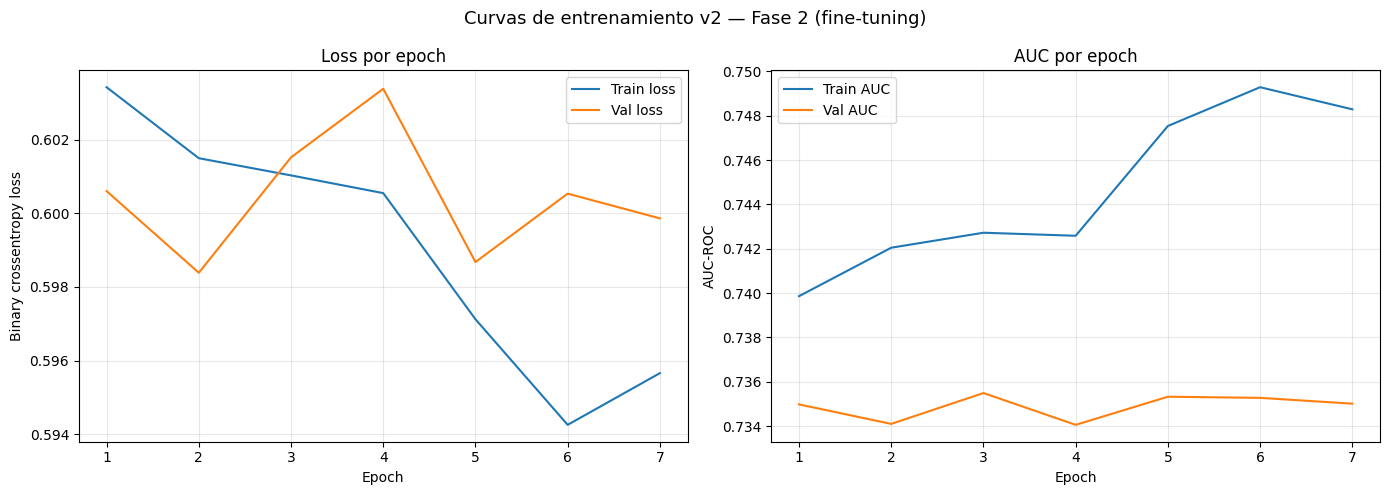

In [13]:
def graficar_una_fase(historia, titulo_fase):
    """Grafica una sola fase cuando no se tiene el historial de ambas."""
    epochs = range(1, len(historia.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, historia.history["loss"],     label="Train loss")
    ax1.plot(epochs, historia.history["val_loss"], label="Val loss")
    ax1.set_title("Loss por epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, historia.history["auc"],     label="Train AUC")
    ax2.plot(epochs, historia.history["val_auc"], label="Val AUC")
    ax2.set_title("AUC por epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC-ROC")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f"Curvas de entrenamiento v2 — {titulo_fase}", fontsize=13)
    plt.tight_layout()
    ruta_grafica = ruta_checkpoints / NOMBRE_CURVAS
    plt.savefig(str(ruta_grafica), dpi=150, bbox_inches="tight")
    print(f"Grafica guardada en: {ruta_grafica}")
    plt.show()

def graficar_ambas_fases(historia_f1, historia_f2):
    """Grafica las dos fases combinadas con linea divisoria."""
    loss_train = historia_f1.history["loss"]     + historia_f2.history["loss"]
    loss_val   = historia_f1.history["val_loss"] + historia_f2.history["val_loss"]
    auc_train  = historia_f1.history["auc"]      + historia_f2.history["auc"]
    auc_val    = historia_f1.history["val_auc"]  + historia_f2.history["val_auc"]
    epochs     = range(1, len(loss_train) + 1)
    fin_fase1  = len(historia_f1.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, loss_train, label="Train loss")
    ax1.plot(epochs, loss_val,   label="Val loss")
    ax1.axvline(x=fin_fase1, color="gray", linestyle="--", alpha=0.6, label="Inicio fine-tuning")
    ax1.set_title("Loss por epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, auc_train, label="Train AUC")
    ax2.plot(epochs, auc_val,   label="Val AUC")
    ax2.axvline(x=fin_fase1, color="gray", linestyle="--", alpha=0.6, label="Inicio fine-tuning")
    ax2.set_title("AUC por epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC-ROC")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Curvas de entrenamiento v2 — DenseNet121 Clasificacion", fontsize=13)
    plt.tight_layout()
    ruta_grafica = ruta_checkpoints / NOMBRE_CURVAS
    plt.savefig(str(ruta_grafica), dpi=150, bbox_inches="tight")
    print(f"Grafica guardada en: {ruta_grafica}")
    plt.show()

# Intentar graficar ambas fases; si no existe historia_fase1 (ejecucion en dos dias)
# graficar solo la fase disponible
try:
    graficar_ambas_fases(historia_fase1, historia_fase2)
except NameError:
    print("historia_fase1 no disponible (entrenamiento en dos dias).")
    print("Graficando solo la Fase 2.")
    graficar_una_fase(historia_fase2, "Fase 2 (fine-tuning)")

## Celda 15 — Evaluacion en test

Cargamos el mejor modelo guardado por el checkpoint y lo evaluamos
en los conjuntos de test que el modelo nunca vio durante el entrenamiento.

Metricas reportadas:
- Loss: valor de la funcion de costo
- Accuracy: porcentaje de predicciones correctas
- AUC-ROC: que tan bien el modelo separa las dos clases independientemente
  del umbral de decision. 0.5 = aleatorio, 1.0 = perfecto.
  CheXNet (Stanford, dataset completo) reporto ~0.84 en promedio.

In [14]:
print(f"Cargando mejor modelo desde: {ruta_mejor_modelo}")
mejor_modelo = load_model(str(ruta_mejor_modelo))

print("\nEvaluacion en test NIH (patient-level split):")
resultados_nih = mejor_modelo.evaluate(flujo_test_nih, verbose=1)
nombres_metricas = mejor_modelo.metrics_names
for nombre, valor in zip(nombres_metricas, resultados_nih):
    print(f"  {nombre}: {valor:.4f}")

print("\nEvaluacion en test Chest X-Ray (validacion externa):")
resultados_chest = mejor_modelo.evaluate(flujo_chest_test, verbose=1)
for nombre, valor in zip(nombres_metricas, resultados_chest):
    print(f"  {nombre}: {valor:.4f}")

print()
print("Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray")
print("refleja la capacidad de generalizacion a un dataset diferente.")

Cargando mejor modelo desde: /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v2.h5



Evaluacion en test NIH (patient-level split):
636/636 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - accuracy: 0.6823 - auc: 0.7269 - loss: 0.6056
  loss: 0.6056
  compile_metrics: 0.6823

Evaluacion en test Chest X-Ray (validacion externa):
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - accuracy: 0.6635 - auc: 0.6888 - loss: 0.6087
  loss: 0.6087
  compile_metrics: 0.6635

Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray
refleja la capacidad de generalizacion a un dataset diferente.


## Celda 16 — Matriz de confusion y metricas clinicas

La celda anterior reporto AUC y accuracy, que son metricas globales.
Esta celda profundiza con metricas mas interpretables en contexto medico.

La matriz de confusion desglosa las predicciones en cuatro categorias:
- Verdaderos positivos (TP): anomalias correctamente detectadas
- Verdaderos negativos (TN): casos normales correctamente identificados
- Falsos positivos (FP): normales clasificados erroneamente como anomalos
- Falsos negativos (FN): anomalias que el modelo no detecto

De estas cuatro categorias se derivan dos metricas clave en diagnostico:
- Sensibilidad: de todos los pacientes anomalos reales, que fraccion detecto
  el modelo. Un falso negativo (anomalia no detectada) es mas peligroso
  clinicamente que un falso positivo.
- Especificidad: de todos los pacientes normales reales, que fraccion identifico
  correctamente. Un valor bajo genera alarmas innecesarias.

El umbral de decision es 0.5: si la probabilidad predicha es mayor a 0.5
el modelo clasifica como anomalia. Este umbral es ajustable.

Generando predicciones en test NIH...
636/636 ━━━━━━━━━━━━━━━━━━━━ 58s 70ms/step

Matriz de confusion (test NIH):
  Verdaderos negativos (TN): 4,433  — normales correctamente identificados
  Falsos positivos    (FP): 1,433  — normales clasificados como anomalos
  Falsos negativos    (FN): 1,799  — anomalos clasificados como normales
  Verdaderos positivos (TP): 2,508  — anomalos correctamente identificados

Metricas clinicas:
  Sensibilidad (Recall)  : 0.582
  Especificidad          : 0.756
  Precision              : 0.636
  F1-Score               : 0.608

Comparacion con modelo v1:
  Metrica        v1      v2
  Sensibilidad   0.544   0.582
  Especificidad  0.790   0.756
  Precision      0.649   0.636
  F1-Score       0.592   0.608

Matriz guardada en: /content/drive/MyDrive/Vena/checkpoints/matriz_confusion_clasificacion_v2.png


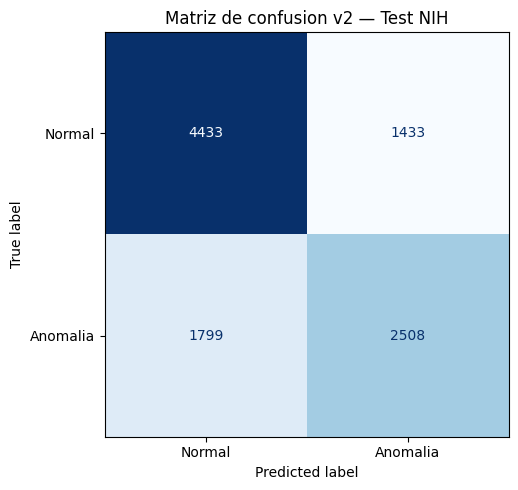


--- Validacion externa: Chest X-Ray ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step
  Sensibilidad : 0.872
  Especificidad: 0.316

              precision    recall  f1-score   support

      Normal       0.60      0.32      0.41       234
    Anomalia       0.68      0.87      0.76       390

    accuracy                           0.66       624
   macro avg       0.64      0.59      0.59       624
weighted avg       0.65      0.66      0.63       624



In [15]:
# --- Predicciones en test NIH ---
print("Generando predicciones en test NIH...")
flujo_test_nih.reset()
probabilidades = mejor_modelo.predict(flujo_test_nih, verbose=1)
probabilidades = probabilidades[:len(df_test_nih)]

etiquetas_reales    = df_test_nih["tiene_anomalia"].values
etiquetas_predichas = (probabilidades.flatten() >= 0.5).astype(int)

cm = confusion_matrix(etiquetas_reales, etiquetas_predichas)
tn, fp, fn, tp = cm.ravel()

print(f"\nMatriz de confusion (test NIH):")
print(f"  Verdaderos negativos (TN): {tn:,}  — normales correctamente identificados")
print(f"  Falsos positivos    (FP): {fp:,}  — normales clasificados como anomalos")
print(f"  Falsos negativos    (FN): {fn:,}  — anomalos clasificados como normales")
print(f"  Verdaderos positivos (TP): {tp:,}  — anomalos correctamente identificados")

sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision     = tp / (tp + fp)
f1            = 2 * (precision * sensibilidad) / (precision + sensibilidad)

print(f"\nMetricas clinicas:")
print(f"  Sensibilidad (Recall)  : {sensibilidad:.3f}")
print(f"  Especificidad          : {especificidad:.3f}")
print(f"  Precision              : {precision:.3f}")
print(f"  F1-Score               : {f1:.3f}")

# --- Comparacion con modelo v1 ---
print(f"\nComparacion con modelo v1:")
print(f"  Metrica        v1      v2")
print(f"  Sensibilidad   0.544   {sensibilidad:.3f}")
print(f"  Especificidad  0.790   {especificidad:.3f}")
print(f"  Precision      0.649   {precision:.3f}")
print(f"  F1-Score       0.592   {f1:.3f}")

# --- Grafica ---
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalia"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de confusion v2 — Test NIH", fontsize=12)
plt.tight_layout()
ruta_matriz = ruta_checkpoints / NOMBRE_MATRIZ
plt.savefig(str(ruta_matriz), dpi=150, bbox_inches="tight")
print(f"\nMatriz guardada en: {ruta_matriz}")
plt.show()

# --- Validacion externa: Chest X-Ray ---
print("\n--- Validacion externa: Chest X-Ray ---")
flujo_chest_test.reset()
probabilidades_chest   = mejor_modelo.predict(flujo_chest_test, verbose=1)
probabilidades_chest   = probabilidades_chest[:len(df_chest_test)]
etiquetas_reales_chest = flujo_chest_test.labels
etiquetas_pred_chest   = (probabilidades_chest.flatten() >= 0.5).astype(int)

cm_chest = confusion_matrix(etiquetas_reales_chest, etiquetas_pred_chest)
tn_c, fp_c, fn_c, tp_c = cm_chest.ravel()
print(f"  Sensibilidad : {tp_c / (tp_c + fn_c):.3f}")
print(f"  Especificidad: {tn_c / (tn_c + fp_c):.3f}")
print()
print(classification_report(
    etiquetas_reales_chest, etiquetas_pred_chest,
    target_names=["Normal", "Anomalia"]
))

## Celda 17 — Guardar backbone v2

Extrae el backbone del mejor modelo y lo guarda por separado.
El backbone tiene salida (None, 7, 7, 1024) — los notebooks NB03 y NB04
deben agregar un GlobalAveragePooling2D antes de su cabeza respectiva
para convertir ese mapa de features en un vector de 1024 dimensiones.

In [16]:
ruta_backbone_v2 = ruta_checkpoints / NOMBRE_BACKBONE

if ruta_backbone_v2.exists():
    tamano_mb = ruta_backbone_v2.stat().st_size / (1024 * 1024)
    print(f"backbone_densenet121_v2.h5 ya existe ({tamano_mb:.1f} MB). No se sobreescribe.")
else:
    # Reconstruir el backbone como Model independiente
    nombre_ultima_capa = "bn"
    try:
        capa_salida = mejor_modelo.get_layer(nombre_ultima_capa)
    except ValueError:
        nombres = [l.name for l in mejor_modelo.layers]
        idx_pool = next(i for i, n in enumerate(nombres) if "global_average" in n)
        capa_salida = mejor_modelo.layers[idx_pool - 1]

    backbone_v2 = Model(
        inputs=mejor_modelo.input,
        outputs=capa_salida.output,
        name="backbone_densenet121_v2"
    )
    backbone_v2.save(str(ruta_backbone_v2))
    print(f"Backbone v2 guardado en: {ruta_backbone_v2}")
    print(f"  Entrada: {backbone_v2.input_shape}")
    print(f"  Salida : {backbone_v2.output_shape}")

print()
print("Archivos generados por este notebook (v2):")
for archivo in sorted(ruta_checkpoints.iterdir()):
    if "v2" in archivo.name:
        tamano_mb = archivo.stat().st_size / (1024 * 1024)
        print(f"  {archivo.name} ({tamano_mb:.1f} MB)")

Backbone v2 guardado en: /content/drive/MyDrive/Vena/checkpoints/backbone_densenet121_v2.h5
  Entrada: (None, 224, 224, 3)
  Salida : (None, 7, 7, 1024)

Archivos generados por este notebook (v2):
  backbone_densenet121_v2.h5 (28.1 MB)
  curvas_entrenamiento_clasificacion_v2.png (0.1 MB)
  matriz_confusion_clasificacion_v2.png (0.0 MB)
  mejor_modelo_clasificacion_v2.h5 (38.6 MB)
